# NBA Analysis project

This is a project from codecademy that I am going to use for practice with statistics. 


In [155]:
# Data manipulation imports
import pandas as pd
import numpy as np

#file path handling
from pathlib import Path

# Importing os
import os

# Visualization
import matplotlib.pyplot as plt

In [156]:
#getting file path
os.getcwd()


'/Users/shamodc/statistics_practice/notebooks'

In [157]:
# Checking what notebooks sees
os.listdir()

['Untitled.ipynb', '.ipynb_checkpoints']

In [158]:
# Cleaning relative paths
BASE_DIR = Path.cwd()

csv_path = BASE_DIR.parent / "data" / "nba_games.csv"


In [159]:
# Loading csv
df = pd.read_csv(csv_path)

# Printing first five rows
df.head()


,game_id,year_id,fran_id,opp_fran,game_location,is_playoffs,pts,opp_pts,game_result,forecast,point_diff
0,194611010TRH,1947,Knicks,Huskies,A,0,68,66,W,0.359935,2
1,194611020CHS,1947,Knicks,Stags,A,0,47,63,L,0.368899,-16
2,194611020PRO,1947,Celtics,Steamrollers,A,0,53,59,L,0.359935,-6
3,194611050BOS,1947,Celtics,Stags,H,0,55,57,L,0.620204,-2
4,194611070STB,1947,Knicks,Bombers,A,0,68,63,W,0.339290,5


In [160]:
# determining the shape of our dataset
rows, cols = df.shape
print(f'This dataframe has {rows} rows and {cols} cols')

This dataframe has 24359 rows and 11 cols


In [161]:
print('These are our columns:')
for col in df.columns:
    print(f'- {col}')

These are our columns:
- game_id
- year_id
- fran_id
- opp_fran
- game_location
- is_playoffs
- pts
- opp_pts
- game_result
- forecast
- point_diff


In [162]:
# Duplicates
num_of_duplicates = df.duplicated().sum()
print(f'These are the number of duplicates: {num_of_duplicates}')

These are the number of duplicates: 0


In [163]:
# DataFrame, create two series named knicks_pts_10 (fran_id = "Knicks") and nets_pts_10(fran_id = "Nets") that represent the points each team has scored in their games.

# Creating yearly subset for 2010
nba_games_2010 = df[df['year_id'] == 2010]

# knicks_pts_10 = df[df.fran_id == 'Knicks']['pts']
knicks_pts_10 = nba_games_2010.loc[nba_games_2010["fran_id"] == "Knicks", "pts"]
print("Knicks games:", knicks_pts_10.shape[0])

#nets_pts_10 = df[df.fran_id == 'Nets']['pts']
nets_pts_10 = nba_games_2010.loc[nba_games_2010["fran_id"] == "Nets", "pts"]
print("Nets games:", nets_pts_10.shape[0])

Knicks games: 82
Nets games: 82


In [164]:
# Getting average points of Knicks and Nets
avg_Knicks_10 = knicks_pts_10.mean()
avg_Nets_10 = nets_pts_10.mean()

print(f'Average Knicks Points: {avg_Knicks_10:.1f}')
print(f'Average Nets Point: {avg_Nets_10:.1f}')

# Calculate the mean difference between the two teams
diff_means_2010 = avg_Knicks_10 - avg_Nets_10
print(f'Difference in averages is {diff_means_2010:.2f}')

Average Knicks Points: 102.1
Average Nets Point: 92.4
Difference in averages is 9.73


### Interpretation

The Knicks average approximately 9.7 more points per game than the Nets in the 2010 dataset. This suggests that the Knicks tend to score more points per game than the Nets on average.

However, without examining the full distributions, it is not yet clear whether this difference is consistent across games or influenced by variability or outliers.

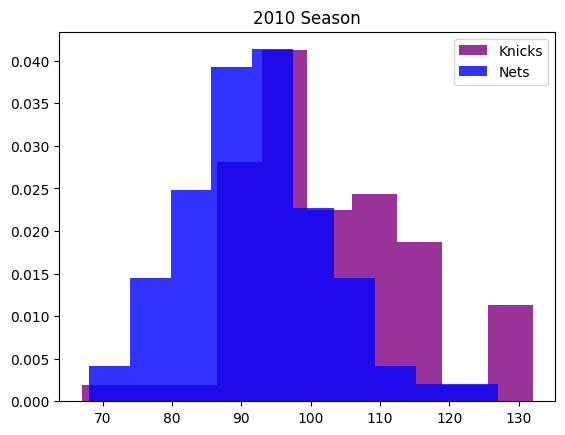

In [165]:
# Create a set of overlapping histograms 
plt.hist(knicks_pts_10, alpha=0.8, density=True, color='purple', label='Knicks')
plt.hist(nets_pts_10, alpha=0.8, density=True, color='blue', label='Nets')
plt.legend()
plt.title("2010 Season")
plt.show()

### Interpretation

# Do the Distributions appear to be the same?

The histograms show moderate overlap between the Knicks and Nets distributions; however, the Knicks distribution is shifted to the right, indicating higher point values overall, while the Nets distribution is shifted to the left.

This pattern is consistent with the observed difference in means (~9–10 points), suggesting that franchise identity is associated with differences in points scored per game, although the overlap indicates that this relationship is not perfectly separable at the game level.

In [166]:
# comparing the 2010 games to the 2014 games
# First we replicate the steps we did for 2010 games

nba_games_2014 = df[df['year_id'] == 2014]
# knicks_pts_14 = df[df.fran_id == 'Knicks']['pts']
knicks_pts_14 = nba_games_2014.loc[nba_games_2014["fran_id"] == "Knicks", "pts"]
print("Knicks games:", knicks_pts_14.shape[0])

#nets_pts_14 = df[df.fran_id == 'Nets']['pts']
nets_pts_14 = nba_games_2014.loc[nba_games_2014["fran_id"] == "Nets", "pts"]
print("Nets games:", nets_pts_14.shape[0])

Knicks games: 82
Nets games: 94


In [167]:
# Getting average points of Knicks and Nets
avg_Knicks_14 = knicks_pts_14.mean()
avg_Nets_14 = nets_pts_14.mean()

print(f'Average Knicks Points: {avg_Knicks_14:.1f}')
print(f'Average Nets Point: {avg_Nets_14:.1f}')

# Calculate the mean difference between the two teams
diff_means_2014 = avg_Knicks_14 - avg_Nets_14
print(f'Difference in averages is {diff_means_2014:.2f}')

Average Knicks Points: 98.6
Average Nets Point: 98.1
Difference in averages is 0.45


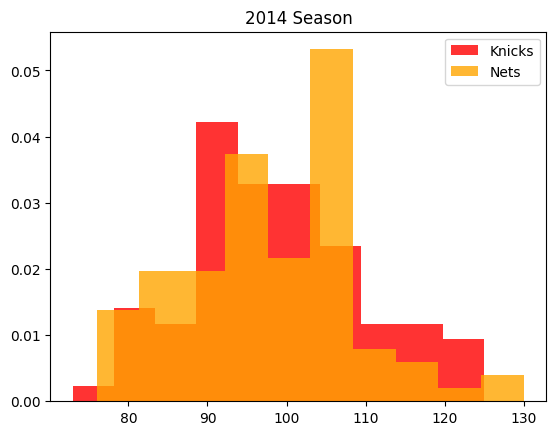

In [168]:
# Creating set of overlapping histograms for the 2014
plt.hist(knicks_pts_14, alpha=0.8, density=True, color='red', label='Knicks')
plt.hist(nets_pts_14, alpha=0.8, density=True, color='orange', label='Nets')
plt.legend()
plt.title("2014 Season")
plt.show()

### Interpretation

The 2014 histograms show greater overlap between the Knicks and Nets distributions compared to 2010, suggesting less separation in scoring behavior between the teams at the distribution level.

However, the Nets distribution appears bimodal, indicating two distinct scoring regimes or higher variability in performance, while the Knicks distribution is more unimodal and concentrated, suggesting more consistent scoring output.

Overall, while there may still be differences in average points scored, the distributional shapes suggest that variability and game-to-game consistency are important factors in understanding team performance.

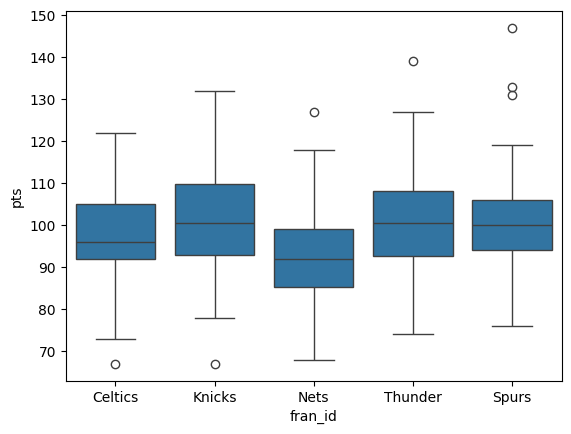

In [169]:
# Creating Box Plots
# Clean plots on top of matplotlib
import seaborn as sns

plt.clf() #to clear the previous plot
sns.boxplot(data = nba_games_2010, x = 'fran_id', y = 'pts')
plt.show()


### Interpretation

In [ ]:
# Contingency table and frequencies
